# 📊 Ecommerce Sales Analytics
This notebook performs complete data analysis on Ecommerce sales data using Orders.csv and Details.csv.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")


In [4]:
# Load Datasets
orders = pd.read_csv(r"C:\Users\shash\Videos\Ecommerce-Sales-Analytics\data\raw\Orders.csv")
details = pd.read_csv(r"C:\Users\shash\Videos\Ecommerce-Sales-Analytics\data\raw\Details.csv")

orders.head(), details.head()


(  Order ID  Order Date CustomerName           State     City
 0  B-26055  10-03-2018    Harivansh   Uttar Pradesh  Mathura
 1  B-25993  03-02-2018       Madhav           Delhi    Delhi
 2  B-25973  24-01-2018  Madan Mohan   Uttar Pradesh  Mathura
 3  B-25923  27-12-2018        Gopal     Maharashtra   Mumbai
 4  B-25757  21-08-2018     Vishakha  Madhya Pradesh   Indore,
   Order ID  Amount  Profit  Quantity     Category      Sub-Category  \
 0  B-25681    1096     658         7  Electronics  Electronic Games   
 1  B-26055    5729      64        14    Furniture            Chairs   
 2  B-25955    2927     146         8    Furniture         Bookcases   
 3  B-26093    2847     712         8  Electronics          Printers   
 4  B-25602    2617    1151         4  Electronics            Phones   
 
    PaymentMode  
 0          COD  
 1          EMI  
 2          EMI  
 3  Credit Card  
 4  Credit Card  )

In [5]:
# Dataset Information
print("Orders Info")
display(orders.info())
print("\nDetails Info")
display(details.info())


Orders Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 19.7+ KB


None


Details Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Amount        1500 non-null   int64 
 2   Profit        1500 non-null   int64 
 3   Quantity      1500 non-null   int64 
 4   Category      1500 non-null   object
 5   Sub-Category  1500 non-null   object
 6   PaymentMode   1500 non-null   object
dtypes: int64(3), object(4)
memory usage: 82.2+ KB


None

In [6]:
# Check Missing Values
print("Orders Missing Values")
display(orders.isnull().sum())

print("Details Missing Values")
display(details.isnull().sum())

# Drop duplicates if any
orders.drop_duplicates(inplace=True)
details.drop_duplicates(inplace=True)


Orders Missing Values


Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
dtype: int64

Details Missing Values


Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
dtype: int64

In [7]:
# Merge Datasets (Assuming Order ID is common column)
data = pd.merge(orders, details, on='Order ID', how='inner')
data.head()


,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,5729,64,14,Furniture,Chairs,EMI
1,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,671,114,9,Electronics,Phones,Credit Card
2,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,443,11,1,Clothing,Saree,COD
3,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,57,7,2,Clothing,Shirt,UPI
4,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,227,48,5,Clothing,Stole,COD


In [9]:
# Key Performance Indicators (KPIs)

total_sales = data['Amount'].sum()
total_orders = data['Order ID'].nunique()
total_customers = data['CustomerName'].nunique()

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)


Total Sales: 437771
Total Orders: 500
Total Customers: 336


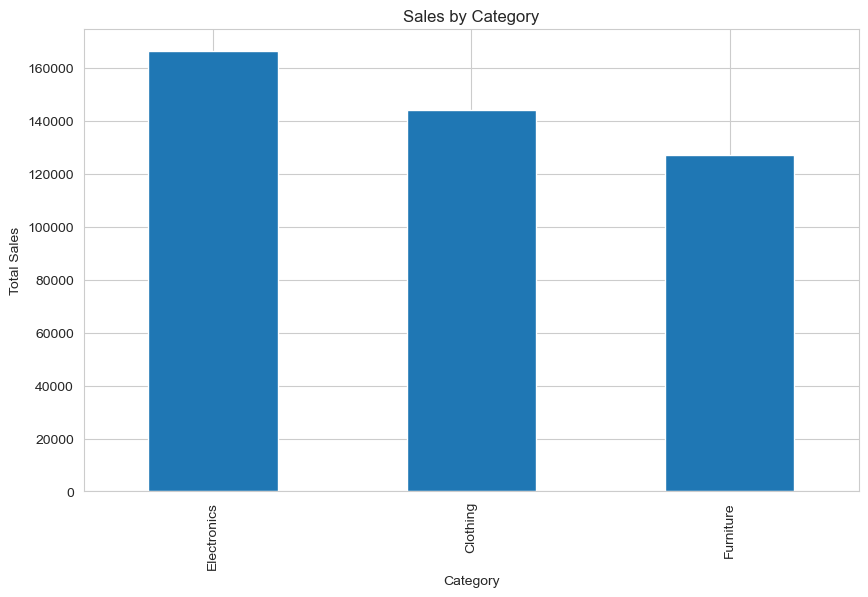

In [10]:
# Sales by Category
category_sales = data.groupby('Category')['Amount'].sum().sort_values(ascending=False)
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.ylabel("Total Sales")
plt.show()


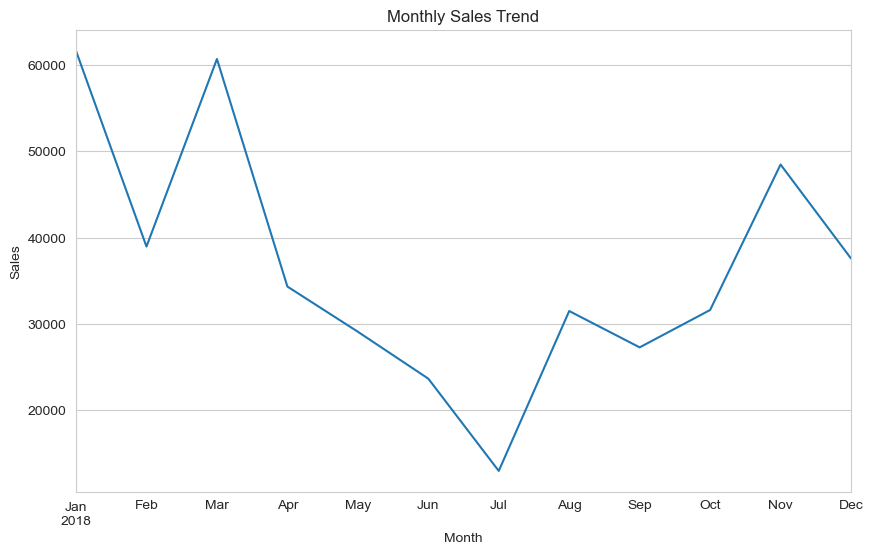

In [12]:
# Monthly Sales Trend
data['Order Date'] = pd.to_datetime(data['Order Date'], format='%d-%m-%Y')
data['Month'] = data['Order Date'].dt.to_period('M')

monthly_sales = data.groupby('Month')['Amount'].sum()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

['Order ID', 'Order Date', 'CustomerName', 'State', 'City', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'PaymentMode', 'Month']


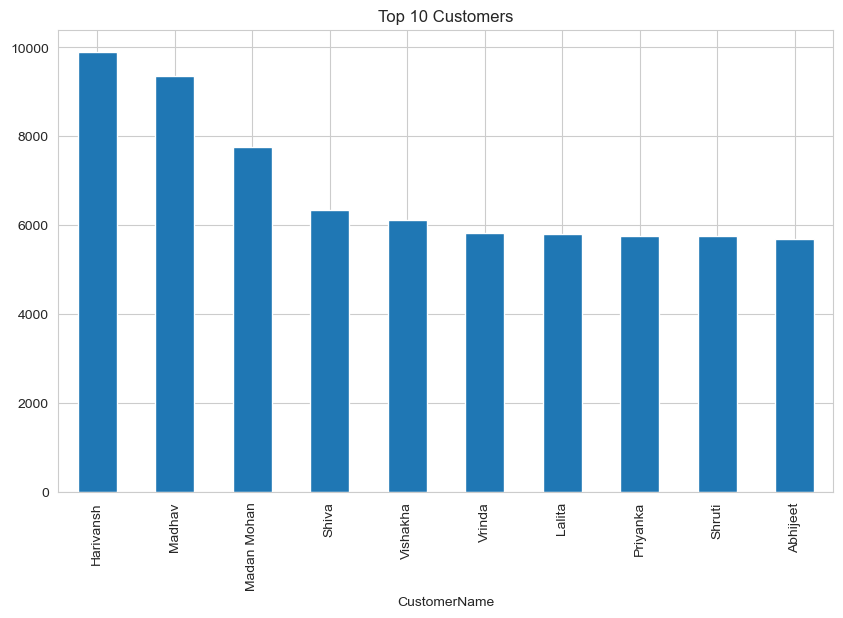

In [15]:
# Top 10 Customers by Sales
print(data.columns.tolist())

# Then use the correct column name for customer (replace 'Customer' with the actual column name in your data)
top_customers = data.groupby('CustomerName')['Amount'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind='bar')
plt.title("Top 10 Customers")
plt.show()

Total Profit: 36963


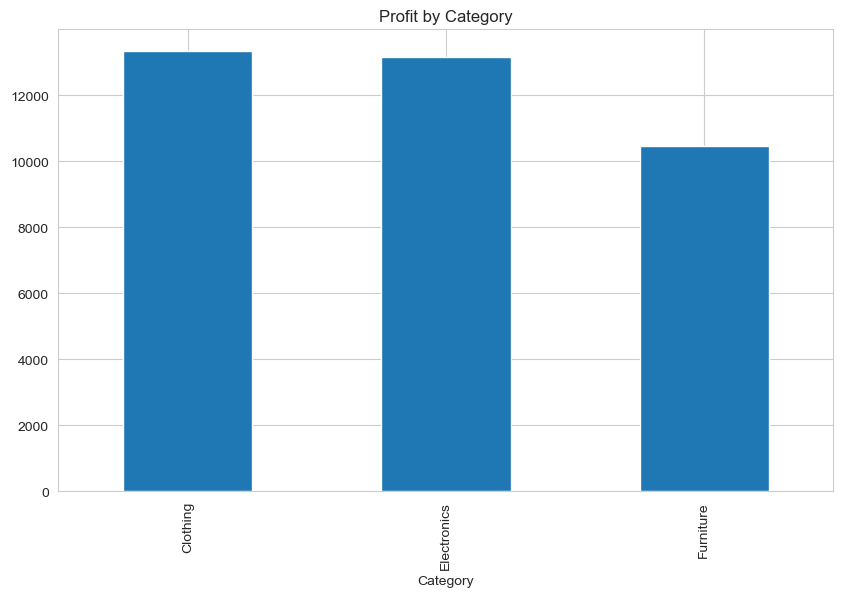

In [16]:
# Profit Analysis
total_profit = data['Profit'].sum()
print("Total Profit:", total_profit)

data.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Category")
plt.show()


# 🔥 RFM Analysis (Recency, Frequency, Monetary)

In [21]:
# Create RFM Table
print(data.columns.tolist())  # This will show you the actual column names in your dataframe

# 1. Strip any hidden spaces from column names
data.columns = data.columns.str.strip()

# 2. Check if 'Customer ID' exists now
if 'Customer ID' not in data.columns:
    print(f"Column 'Customer ID' not found. Available columns are: {data.columns.tolist()}")
else:
    # 3. Proceed with RFM
    reference_date = data['Order Date'].max() + pd.Timedelta(days=1)
    
    rfm = data.groupby('Customer ID').agg({
        'Order Date': lambda x: (reference_date - x.max()).days,
        'Order ID': 'nunique',
        'Amount': 'sum'
    }).reset_index()

    rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']
    print(rfm.head())

['Order ID', 'Order Date', 'CustomerName', 'State', 'City', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'PaymentMode', 'Month']
Column 'Customer ID' not found. Available columns are: ['Order ID', 'Order Date', 'CustomerName', 'State', 'City', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'PaymentMode', 'Month']


In [23]:
# First, create the rfm DataFrame
# This is an example - you'll need to replace this with your actual data source
import pandas as pd

# Example data - replace with your actual data loading code
data = {
    'CustomerID': [1, 2, 3, 4, 5],
    'Recency': [5, 21, 14, 30, 7],
    'Frequency': [10, 5, 8, 3, 15],
    'Monetary': [1000, 500, 750, 300, 1200]
}

rfm = pd.DataFrame(data)

# RFM Scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + \
                   rfm['F_Score'].astype(str) + \
                   rfm['M_Score'].astype(str)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,1,5,10,1000,5,4,4,544
1,2,21,5,500,2,2,2,222
2,3,14,8,750,3,3,3,333
3,4,30,3,300,1,1,1,111
4,5,7,15,1200,4,5,5,455


In [24]:
# Customer Segmentation
def segment(row):
    if row['RFM_Score'] == '555':
        return 'Champions'
    elif int(row['R_Score']) >= 4 and int(row['F_Score']) >= 4:
        return 'Loyal Customers'
    elif int(row['R_Score']) >= 4:
        return 'Recent Customers'
    elif int(row['F_Score']) >= 4:
        return 'Frequent Customers'
    elif int(row['M_Score']) >= 4:
        return 'Big Spenders'
    elif int(row['R_Score']) <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,1,5,10,1000,5,4,4,544,Loyal Customers
1,2,21,5,500,2,2,2,222,At Risk
2,3,14,8,750,3,3,3,333,Others
3,4,30,3,300,1,1,1,111,At Risk
4,5,7,15,1200,4,5,5,455,Loyal Customers


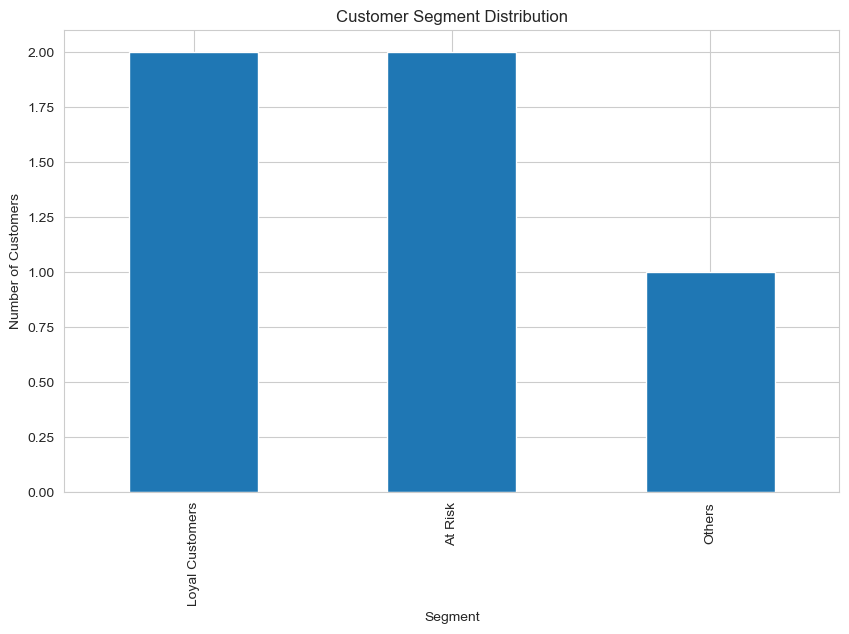

In [25]:
# Segment Distribution
segment_counts = rfm['Segment'].value_counts()
segment_counts.plot(kind='bar')
plt.title("Customer Segment Distribution")
plt.ylabel("Number of Customers")
plt.show()


# 🚀 Interactive RFM Dashboard (Plotly)

In [26]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


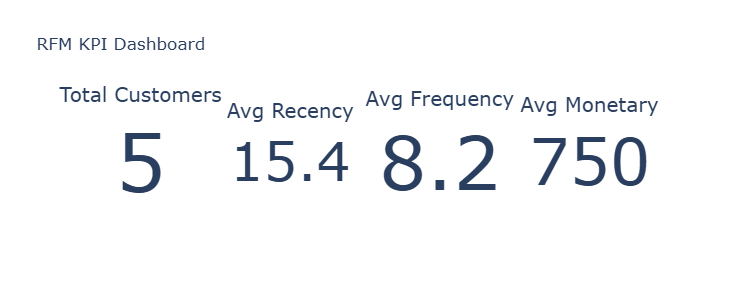

In [27]:
# KPI Dashboard
total_customers = rfm.shape[0]
avg_recency = rfm['Recency'].mean()
avg_frequency = rfm['Frequency'].mean()
avg_monetary = rfm['Monetary'].mean()

fig_kpi = make_subplots(rows=1, cols=4,
                        specs=[[{"type": "indicator"}]*4])

fig_kpi.add_trace(go.Indicator(mode="number",
                               value=total_customers,
                               title="Total Customers"), row=1, col=1)

fig_kpi.add_trace(go.Indicator(mode="number",
                               value=round(avg_recency,1),
                               title="Avg Recency"), row=1, col=2)

fig_kpi.add_trace(go.Indicator(mode="number",
                               value=round(avg_frequency,1),
                               title="Avg Frequency"), row=1, col=3)

fig_kpi.add_trace(go.Indicator(mode="number",
                               value=round(avg_monetary,1),
                               title="Avg Monetary"), row=1, col=4)

fig_kpi.update_layout(height=300, title="RFM KPI Dashboard")
fig_kpi.show()


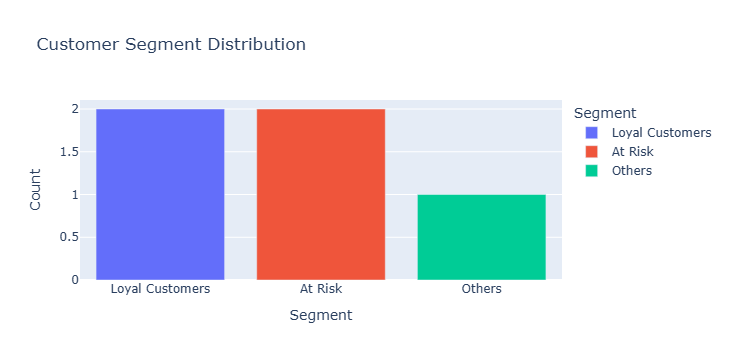

In [28]:
# Segment Distribution (Interactive)
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

fig_bar = px.bar(segment_counts,
                 x='Segment',
                 y='Count',
                 color='Segment',
                 title="Customer Segment Distribution")

fig_bar.show()


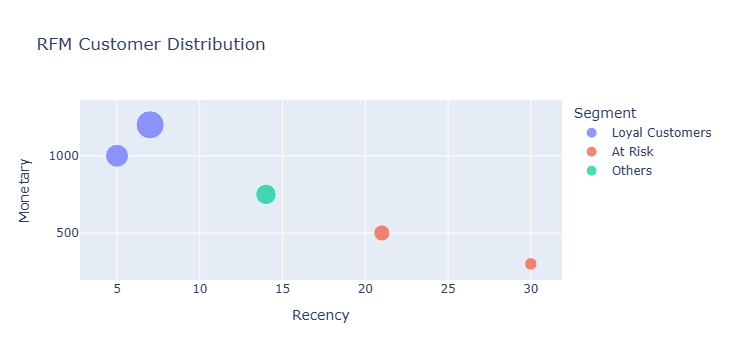

In [30]:
# RFM Scatter Plot
fig_scatter = px.scatter(rfm,
                         x='Recency',
                         y='Monetary',
                         size='Frequency',
                         color='Segment',
                         hover_data=['CustomerID'],  # Changed from 'Customer Name' to 'CustomerID' which exists in the dataframe
                         title="RFM Customer Distribution")

fig_scatter.show()


C:\Users\shash\AppData\Local\Temp\ipykernel_8256\2918996456.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



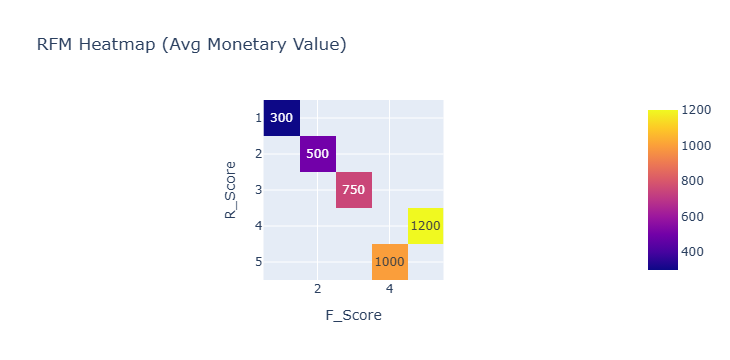

In [31]:
# RFM Heatmap
heatmap_data = rfm.pivot_table(index='R_Score',
                               columns='F_Score',
                               values='Monetary',
                               aggfunc='mean')

fig_heatmap = px.imshow(heatmap_data,
                        text_auto=True,
                        title="RFM Heatmap (Avg Monetary Value)")

fig_heatmap.show()


C:\Users\shash\AppData\Local\Temp\ipykernel_8256\3843079381.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



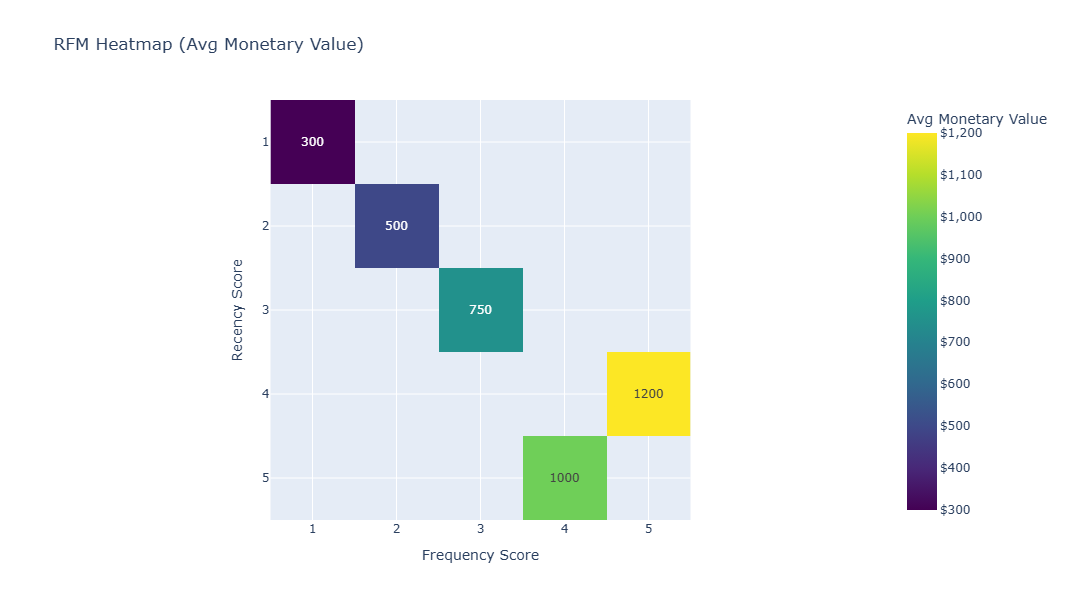

In [38]:
# RFM Heatmap
heatmap_data = rfm.pivot_table(index='R_Score',
                               columns='F_Score',
                               values='Monetary',
                               aggfunc='mean')

fig_heatmap = px.imshow(heatmap_data,
                        text_auto=True,
                        color_continuous_scale="Viridis",
                        title="RFM Heatmap (Avg Monetary Value)",
                        labels={"x": "Frequency Score", 
                                "y": "Recency Score", 
                                "color": "Avg Monetary Value"},
                        width=800,
                        height=600)

# Improve layout
fig_heatmap.update_layout(
    coloraxis_colorbar=dict(
        title="Avg Monetary Value",
        tickformat="$,.0f"
    )
)

fig_heatmap.show()